# MALDROID Machine Learning Notebook

In [60]:
import pandas as pd
import numpy as np
from scipy import stats

# -------------- Load Dataset --------------
cic = pd.read_csv("../datasets/CICMal2017 Dataset - Extracted Features with specified APK Benign vs Malicious.csv")
cic['dataset'] = "CICAndMal2017"

drebin = pd.read_csv("../datasets/DREBIN Dataset - APK signatures.csv", low_memory=False)
drebin['dataset'] = "Drebin"

amsf = pd.read_csv("../datasets/AMSF Dataset - Extracted Features with Malware signatures (and Benign vs Malicious).csv")
amsf['dataset'] = "AMSF"

am = pd.read_csv("../datasets/AM.csv", sep=";")
am['dataset'] = "AM"


## Data-preprocessing (Benign = 0, Malicious = 1)


In [ ]:
for df in [cic, drebin, am, amsf]:
    df.rename(columns={col: 'class' for col in df.columns if col.lower() in ['label', 'class', 'malware']}, inplace=True)

# ------ CICMAL2017 ------
cic = cic.dropna()

cic_cols = ["App", "Package", "Category", "Description", "Related apps"]
cic = cic.drop(columns=[c for c in cic_cols if c in cic.columns])

binary_map = {
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    'YES': 1, 'NO': 0,
    'Yes': 1, 'No': 0,
    'y': 1, 'n': 0
}
cic = cic.replace(binary_map)

bool_cols = cic.select_dtypes(include='bool').columns
cic[bool_cols] = cic[bool_cols].astype(int)

numeric_cols_cic = ['rating', 'number_of_ratings', 'price',
                'dangerous_permissions_count', 'safe_permissions_count']

def remove_outliers_iqr(df, cols):
    for col in cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            before = df.shape[0]
            df = df[(df[col] >= lower) & (df[col] <= upper)]
            after = df.shape[0]
            print(f"Removed {before - after} outliers from '{col}'")
    return df

cic = remove_outliers_iqr(cic, numeric_cols_cic)

if cic['class'].dtype != int:
    cic['class'] = pd.to_numeric(cic['class'], errors='coerce')
    cic['class'] = cic['class'].fillna(0).astype(int)
    
cic_cleaned = cic.reset_index(drop=True)

# ------ DREBIN ------
drebin['class'] = drebin['class'].replace({'S': 1, 'B': 0})

drebin_cols = ["TelephonyManager.getSimCountryIso"]
drebin = drebin.drop(columns=[d for d in drebin_cols if d in drebin.columns])

# ------ AM ------
am['class'] = am['class'].replace({'malware': 1, 'benignware': 0})

am_cols = [
    "name", ".//MD5", "version", ".//Min_SDK", ".//Min_Screen", ".//Min_OpenGL", 
    ".//Supported_CPU", ".//Signature", ".//Developer", ".//Organization", 
    ".//Locality", ".//Country", ".//State", "description", "rating_number", 
    "rating_count"
]
am = am.drop(columns=[c for c in am_cols if c in am.columns])

am.columns = am.columns.str.strip().str.replace(' ', '_').str.lower()

cols = [c for c in am.columns if c not in ['class', 'dataset']]
am_cleaned = am[cols + ['class'] + ['dataset']]

# ------ AMSF ------
amsf = amsf.fillna(0)

# -------------- Datasets Aggregation --------------
train_df = pd.concat([drebin, cic_cleaned], axis=0, ignore_index=True)
train_df = train_df.fillna(0)

cols = [c for c in train_df.columns if c not in ['class', 'dataset']]
train_df =train_df[cols + ['class'] + ['dataset']]

amsf.sample(5)


,class,android.app.Activity,android.util.Log.v,android.util.Log.e,android.util.Log.d,java.lang.System,java.util.Arrays,android.widget.VideoView,android.view.animation.AnimationSet,android.graphics.Bitmap.compress,...,android.net.NetworkInfo.getState,java.lang.Object.equals,android.location.Criteria,android.util.AttributeSet.getAttributeIntValue,android.database.Cursor.isAfterLast,android.telephony.SmsManager.sendTextMessage,android.app.Activity.onOptionsItemSelected,android.telephony.TelephonyManager.getSubscriberId,android.telephony.SmsMessage.createFromPdu,dataset
1415,0,108.0,65.000000,79.0,17.0,75.0,34,0.0,3,1,...,0,0.0,0,0,0,0,0,0,0,AMSF
3181,1,186.0,46.000000,146.0,227.0,296.0,23,6.0,19,2,...,0,0.0,10,3,0,0,0,6,0,AMSF
795,0,105.0,92.000000,211.0,152.0,516.0,151,0.0,3,2,...,0,182.0,0,0,0,0,0,0,0,AMSF
1735,0,559.0,213.102736,515.0,573.0,545.0,480,0.0,6,9,...,0,0.0,2,4,0,0,5,0,0,AMSF
4088,1,12.0,26.000000,0.0,13.0,4.0,0,0.0,0,0,...,0,0.0,0,0,0,1,0,0,1,AMSF


In [22]:
#train_df.to_csv("Aggregated_MALDROID_Datasets.csv", index=False)

## ML Model Training

### Functions and Parameters

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from mrmr import mrmr_classif
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
pca = PCA(n_components=0.95) 
ros = RandomOverSampler(random_state=42)

# ---------- Random Forest Parameter ----------

def rf_function(X_train_scaled, y_bal, X_test_scaled, y_test, dataset_name):
    rf_params = {
        'n_estimators': randint(100, 500),
        'max_depth': [3, 5, 7],
        'criterion': ['gini', 'entropy']
    }
    rf = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=rf_params, cv=5, n_jobs=-1, verbose=1)
    
    rf = rf.fit(X_train_scaled, y_bal)
    rf_best = rf.best_estimator_
    y_pred = rf_best.predict(X_test_scaled)
    rf_acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n\nRandom Forest Accuracy (Drebin Dataset): {rf_acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Random Forest ({dataset_name} Dataset)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # scores = cross_val_score(rf, X_train_scaled, y_bal, cv=skf, scoring='accuracy', n_jobs=-1)
    # print(scores.mean())


# ---------- KNN Parameter ----------
def knn_function(X_train_scaled, y_bal, X_test_scaled, y_test, dataset_name):
    knn_params = {
        'n_neighbors': randint(3, 9),
        'weights': ['uniform', 'distance' ],
        'p': [1, 2]
    }
    knn = RandomizedSearchCV(estimator=KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2), param_distributions=knn_params, cv=5, n_jobs=-1, verbose=1, scoring='f1_weighted')
    
    knn = knn.fit(X_train_scaled, y_bal)
    knn_best = knn.best_estimator_
    y_pred = knn_best.predict(X_test_scaled)
    knn_acc = accuracy_score(y_test, y_pred)

    print(f"\n\nKNN Accuracy (Drebin Dataset): {knn_acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - KNN ({dataset_name} Dataset)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # scores = cross_val_score(knn, X_train_scaled, y_bal, cv=skf, scoring='accuracy', n_jobs=-1)
    # print(scores.mean())


# ---------- SVM Parameter ----------
def svm_function(X_train_scaled, y_bal, X_test_scaled, y_test, dataset_name):
    svm = LinearSVC(random_state=42, max_iter=5000)
    
    svm = svm.fit(X_train_scaled, y_bal)
    y_pred = svm.predict(X_test_scaled)
    svm_acc = accuracy_score(y_test, y_pred)

    print(f"\n\nSVM Accuracy ({dataset_name} Dataset): {svm_acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - SVM ({dataset_name} Dataset)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # scores = cross_val_score(svm, X_train_scaled, y_bal, cv=skf, scoring='accuracy', n_jobs=-1)
    # print(scores.mean())


### Drebin Dataset

In [24]:
# -------------- Drebin Variables -----------
X_drebin = drebin.drop(columns=['class', 'dataset'], errors='ignore')
y_drebin = drebin['class']

X_train_drebin, X_test_drebin, y_train_drebin, y_test_drebin = train_test_split(X_drebin, y_drebin, test_size=0.3, random_state=42, stratify=y_drebin ,shuffle=True)

X_bal_drebin, y_bal_drebin = ros.fit_resample(X_train_drebin, y_train_drebin)

selected_features_drebin = mrmr_classif(X=X_bal_drebin, y=y_bal_drebin, K=30, n_jobs=-1, show_progress=True)

print(f"Selected {len(selected_features_drebin)} features using mRMR")
print(selected_features_drebin[:10])

X_train_scale_drebin = scaler.fit_transform(X_bal_drebin[selected_features_drebin])
X_test_scale_drebin = scaler.transform(X_test_drebin[selected_features_drebin])

X_train_scaled_drebin = pca.fit_transform(X_train_scale_drebin)
X_test_scaled_drebin = pca.transform(X_test_scale_drebin)

100%|██████████| 30/30 [00:07<00:00,  4.09it/s]

Selected 30 features using mRMR
['transact', 'RECEIVE_BOOT_COMPLETED', 'SEND_SMS', 'onServiceConnected', 'READ_PHONE_STATE', 'attachInterface', 'bindService', 'android.os.Binder', 'ServiceConnection', 'Ljava.lang.Class.getCanonicalName']


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (Drebin Dataset): 0.9481

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2843
           1       0.93      0.93      0.93      1668

    accuracy                           0.95      4511
   macro avg       0.95      0.94      0.94      4511
weighted avg       0.95      0.95      0.95      4511

[[2733  110]
 [ 124 1544]]


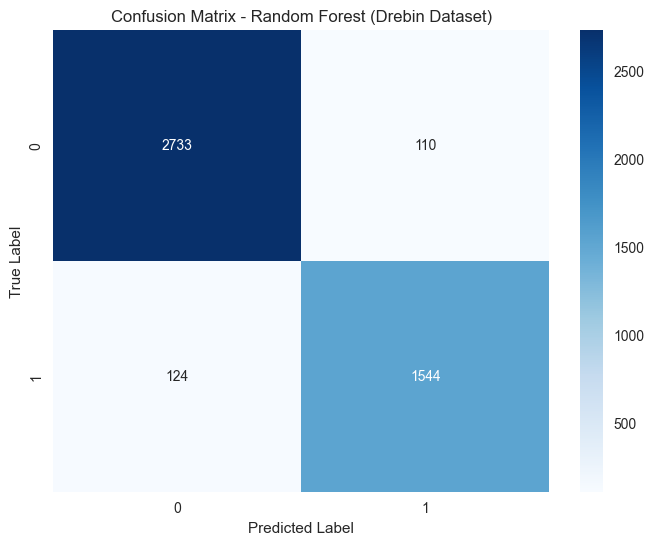

In [25]:
# ----- Drebin Random Forest -----
rf_function(X_train_scaled_drebin, y_bal_drebin, X_test_scaled_drebin, y_test_drebin, "Drebin")

#### K-Nearest Neighbour Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (Drebin Dataset): 0.9590

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2843
           1       0.95      0.94      0.94      1668

    accuracy                           0.96      4511
   macro avg       0.96      0.95      0.96      4511
weighted avg       0.96      0.96      0.96      4511

[[2760   83]
 [ 102 1566]]


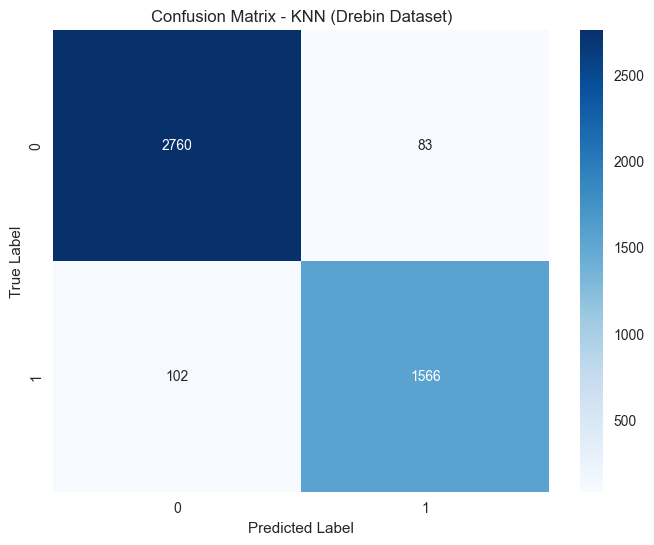

In [26]:
# -------------- Drebin KNN Classifier -----------
knn_function(X_train_scaled_drebin, y_bal_drebin, X_test_scaled_drebin, y_test_drebin, "Drebin")

#### SVM Classifier



SVM Accuracy (Drebin Dataset): 0.9266

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2843
           1       0.89      0.92      0.90      1668

    accuracy                           0.93      4511
   macro avg       0.92      0.92      0.92      4511
weighted avg       0.93      0.93      0.93      4511

[[2650  193]
 [ 138 1530]]


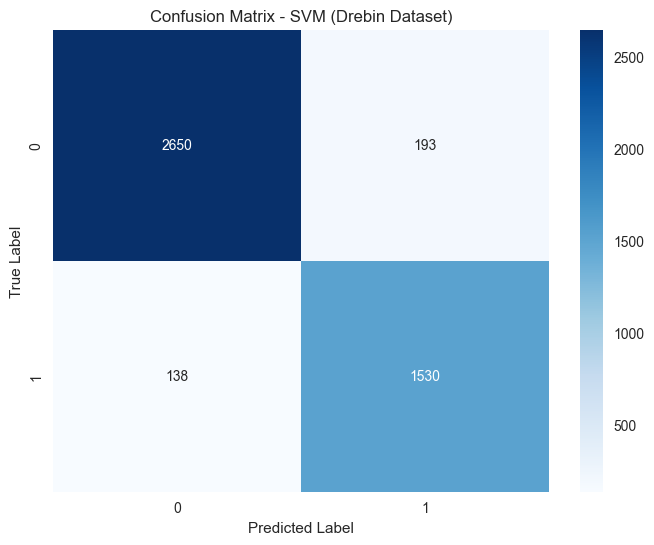

In [27]:
# ------ Drebin SVM Classifier -----------
svm_function(X_train_scaled_drebin, y_bal_drebin, X_test_scaled_drebin, y_test_drebin, "Drebin")

### AM Dataset

In [28]:
# -------------- AM Variables --------------
X_am = am_cleaned.drop(columns=['class', 'dataset'], errors='ignore')
y_am = am_cleaned['class']

X_train_am, X_test_am, y_train_am, y_test_am = train_test_split(X_am, y_am, test_size=0.3, random_state=42, stratify=y_am ,shuffle=True)

X_bal_am, y_bal_am = ros.fit_resample(X_train_am, y_train_am)

selected_features_am = mrmr_classif(X=X_bal_am, y=y_bal_am, K=30, n_jobs=-1, show_progress=True)

print(f"Selected {len(selected_features_am)} features using mRMR")
print(selected_features_am[:10])

X_train_scale_am = scaler.fit_transform(X_bal_am[selected_features_am])
X_test_scale_am = scaler.transform(X_test_am[selected_features_am])

pca = PCA(n_components=0.95) 
X_train_scaled_am = pca.fit_transform(X_train_scale_am)
X_test_scaled_am = pca.transform(X_test_scale_am)

100%|██████████| 30/30 [00:03<00:00,  9.02it/s]

Selected 30 features using mRMR
['com.android.launcher.permission.uninstall_shortcut', 'com.android.launcher.permission.install_shortcut', 'android.permission.manage_accounts', 'android.permission.read_sync_settings', 'android.permission.write_sync_settings', 'android.permission.authenticate_accounts', 'android.permission.read_logs', 'android.permission.use_credentials', 'android.permission.get_accounts', 'android.permission.read_phone_state']


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (Drebin Dataset): 0.8905

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2418
           1       0.82      0.82      0.82      1025

    accuracy                           0.89      3443
   macro avg       0.87      0.87      0.87      3443
weighted avg       0.89      0.89      0.89      3443

[[2228  190]
 [ 187  838]]


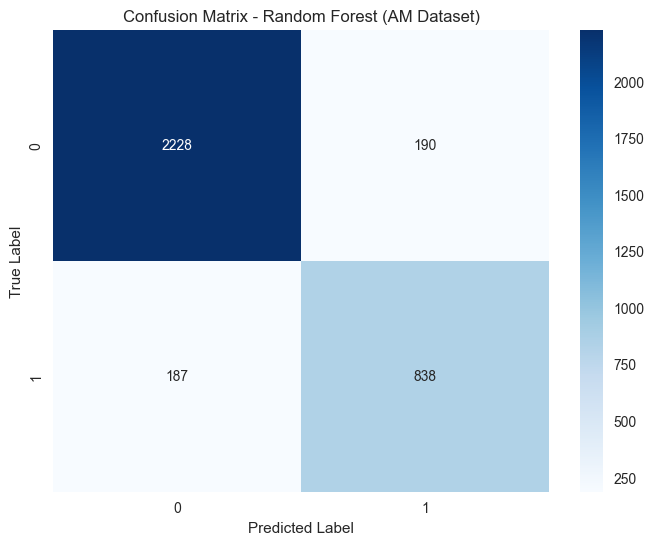

In [29]:
# ----- AM Random Forest -----
rf_function(X_train_scaled_am, y_bal_am, X_test_scaled_am, y_test_am, "AM")

#### K-Nearest Neighbour Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (Drebin Dataset): 0.8960

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      2418
           1       0.87      0.77      0.81      1025

    accuracy                           0.90      3443
   macro avg       0.89      0.86      0.87      3443
weighted avg       0.89      0.90      0.89      3443

[[2300  118]
 [ 240  785]]


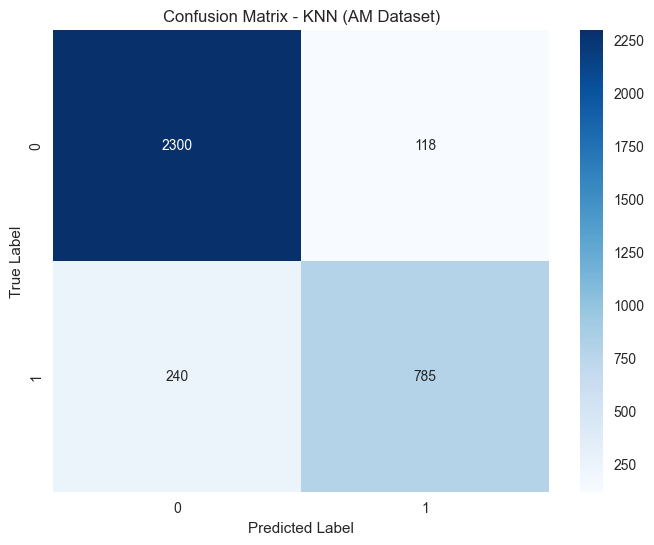

In [30]:
# ------ AM KNN Classifier -----------
knn_function(X_train_scaled_am, y_bal_am, X_test_scaled_am, y_test_am, "AM")

#### SVM Classifier



SVM Accuracy (AM Dataset): 0.8757

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      2418
           1       0.87      0.69      0.77      1025

    accuracy                           0.88      3443
   macro avg       0.87      0.82      0.84      3443
weighted avg       0.88      0.88      0.87      3443

[[2310  108]
 [ 320  705]]


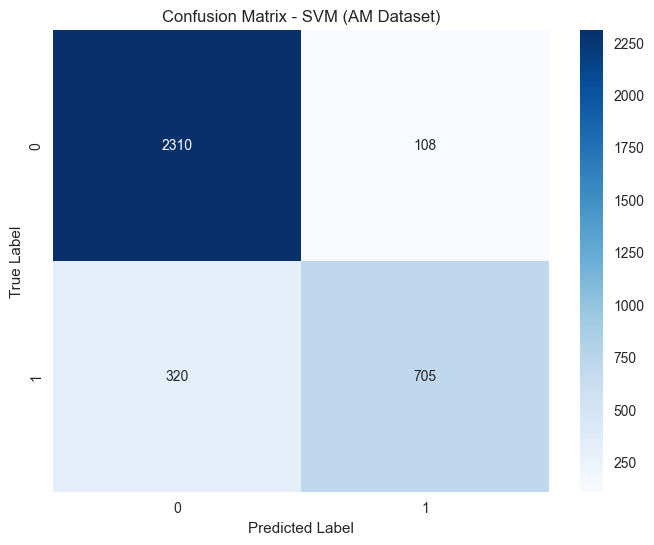

In [31]:
# ------ AM SVM Classifier -----------
svm_function(X_train_scaled_am, y_bal_am, X_test_scaled_am, y_test_am, "AM")

### AMSF Dataset

In [54]:
# ------ AMSF Variables -----------
X_amsf = amsf.drop(columns=['class', 'dataset'], errors='ignore')
y_amsf = amsf['class']

X_train_amsf, X_test_amsf, y_train_amsf, y_test_amsf = train_test_split(X_amsf, y_amsf, test_size=0.3, random_state=42, stratify=y_amsf ,shuffle=True)

X_bal_amsf, y_bal_amsf = ros.fit_resample(X_train_amsf, y_train_amsf)

selected_features_amsf = mrmr_classif(X=X_bal_amsf, y=y_bal_amsf, K=30, n_jobs=-1, show_progress=True)

print(f"Selected {len(selected_features_amsf)} features using mRMR")
print(selected_features_amsf[:10])

X_train_scale_amsf = scaler.fit_transform(X_bal_amsf[selected_features_amsf])
X_test_scale_amsf = scaler.transform(X_test_amsf[selected_features_amsf])

X_train_scaled_amsf = pca.fit_transform(X_train_scale_amsf)
X_test_scaled_amsf = pca.transform(X_test_scale_amsf)

100%|██████████| 30/30 [00:07<00:00,  4.03it/s]

Selected 30 features using mRMR
['java.io.PrintWriter', 'android.telephony.SmsManager.sendTextMessage', 'android.view.View.getVisibility', 'android.telephony.SmsManager', 'android.util.Log.v', 'android.view.KeyEvent', 'android.content.Intent.setComponent', 'android.content.Context.getPackageName', 'android.view.animation.AnimationUtils', 'android.content.res.Resources.getDisplayMetrics']


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (Drebin Dataset): 0.9854

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       753
           1       0.99      0.99      0.99       753

    accuracy                           0.99      1506
   macro avg       0.99      0.99      0.99      1506
weighted avg       0.99      0.99      0.99      1506

[[742  11]
 [ 11 742]]


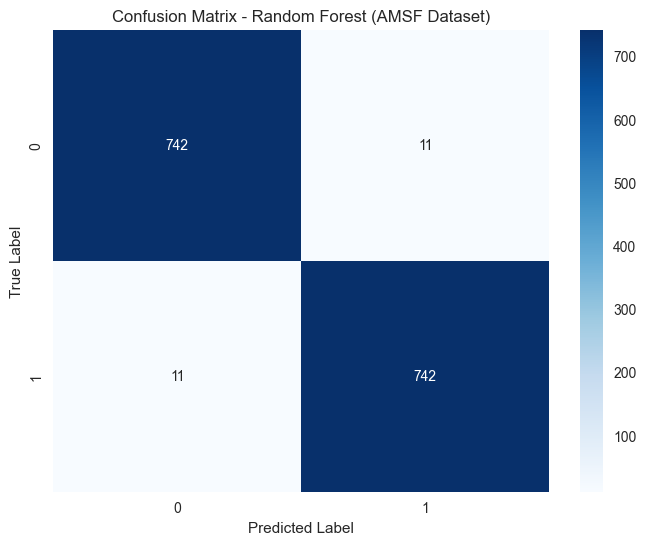

In [55]:
# ------ AMSF Random Forest -----------
rf_function(X_train_scaled_amsf, y_bal_amsf, X_test_scaled_amsf, y_test_amsf, "AMSF")

#### K-Nearest Neighbour Classifier

In [ ]:
# ------ AMSF KNN Classifier -----------
knn_function(X_train_scaled_amsf, y_bal_amsf, X_test_scaled_amsf, y_test_amsf, "AMSF")

#### SVM Classifier

In [ ]:
# ------ AMSF SVM Classifier -----------
svm_function(X_train_scaled_amsf, y_bal_amsf, X_test_scaled_amsf, y_test_amsf, "AMSF")

### CICMAL2017 Dataset

In [32]:
# -------------- CIC Variables --------------
X_cic = cic_cleaned.drop(columns=['class', 'dataset'], errors='ignore')
y_cic = cic_cleaned['class']

X_train_cic, X_test_cic, y_train_cic, y_test_cic = train_test_split(X_cic, y_cic, test_size=0.3, random_state=42, stratify=y_cic ,shuffle=True)

X_bal_cic, y_bal_cic = ros.fit_resample(X_train_cic, y_train_cic)

selected_features_cic = mrmr_classif(X=X_bal_cic, y=y_bal_cic, K=30, n_jobs=-1, show_progress=True)

print(f"Selected {len(selected_features_cic)} features using mRMR")
print(selected_features_cic[:10])

X_train_scale_cic = scaler.fit_transform(X_bal_cic[selected_features_cic])
X_test_scale_cic = scaler.transform(X_test_cic[selected_features_cic])

X_train_scaled_cic = pca.fit_transform(X_train_scale_cic)
X_test_scaled_cic = pca.transform(X_test_scale_cic)

100%|██████████| 30/30 [00:05<00:00,  5.08it/s]

Selected 30 features using mRMR
['Rating', 'Your location : mock location sources for testing (D)', "Your personal information : write Browser's history and bookmarks (D)", 'Price', 'Network communication : view network state (S)', 'Default : bind to a wallpaper (S)', 'Network communication : full Internet access (D)', 'Default : bind to an input method (S)', 'Default : Access DRM content. (S)', 'Default : interact with a device admin (S)']


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (Drebin Dataset): 0.6566

              precision    recall  f1-score   support

           0       0.50      0.87      0.63      2973
           1       0.89      0.55      0.68      5799

    accuracy                           0.66      8772
   macro avg       0.69      0.71      0.66      8772
weighted avg       0.76      0.66      0.66      8772

[[2594  379]
 [2633 3166]]


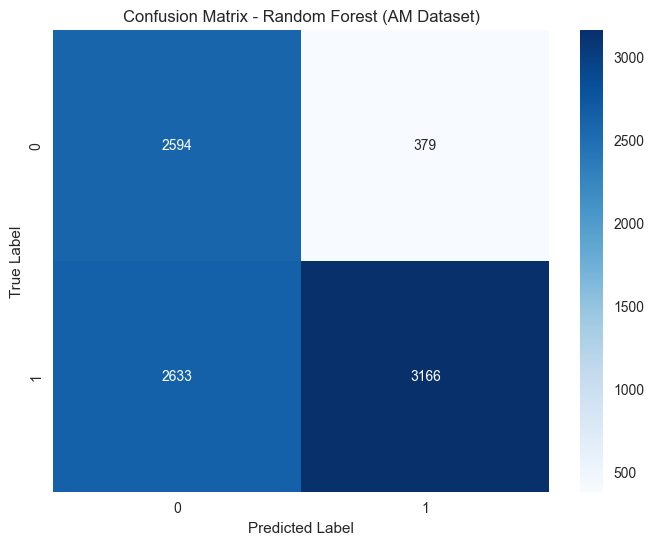

In [33]:
# ----- CIC Random Forest -----
rf_function(X_train_scaled_cic, y_bal_cic, X_test_scaled_cic, y_test_cic, "AM")

#### K-Nearest Neighbour Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (Drebin Dataset): 0.6960

              precision    recall  f1-score   support

           0       0.55      0.59      0.57      2973
           1       0.78      0.75      0.77      5799

    accuracy                           0.70      8772
   macro avg       0.66      0.67      0.67      8772
weighted avg       0.70      0.70      0.70      8772

[[1746 1227]
 [1440 4359]]


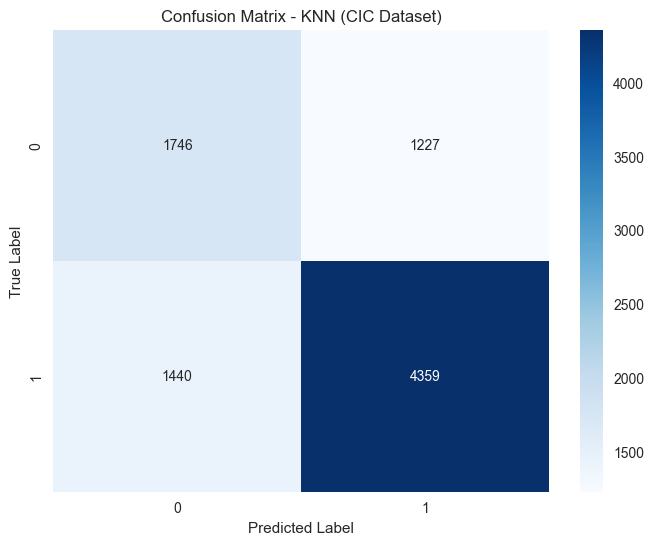

In [34]:
# ------- CIC KNN Classifier --------
knn_function(X_train_scaled_cic, y_bal_cic, X_test_scaled_cic, y_test_cic, "CIC")

#### SVM Classifier



SVM Accuracy (CIC Dataset): 0.6229

              precision    recall  f1-score   support

           0       0.47      0.88      0.61      2973
           1       0.89      0.49      0.63      5799

    accuracy                           0.62      8772
   macro avg       0.68      0.68      0.62      8772
weighted avg       0.75      0.62      0.63      8772

[[2607  366]
 [2942 2857]]


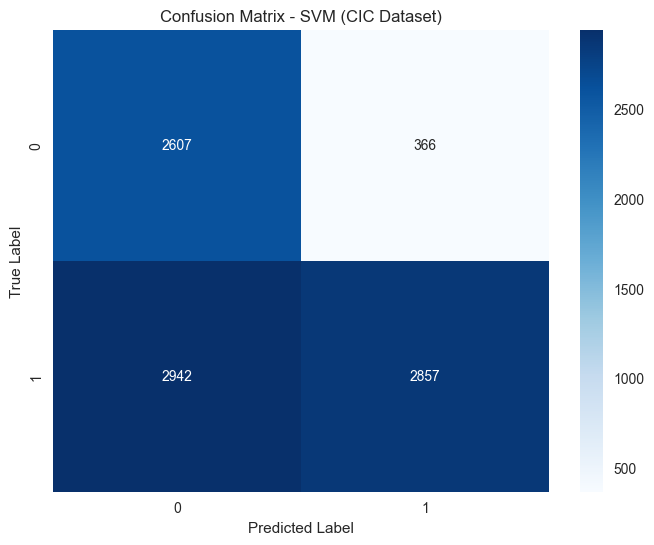

In [35]:
# ------ CIC SVM Classifier -----------
svm_function(X_train_scaled_cic, y_bal_cic, X_test_scaled_cic, y_test_cic, "CIC")

### Combined Dataset

In [ ]:
# ------ Combined Dataset Variables -----------

combined = pd.concat([drebin, am_cleaned], ignore_index=True)
combined = combined.fillna(0)
X_combined = combined.drop(columns=['class', 'dataset'], errors='ignore')
y_combined = combined['class']

X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(X_combined, y_combined, test_size=0.3, random_state=42, stratify=y_combined ,shuffle=True)

X_bal_combined, y_bal_combined = ros.fit_resample(X_train_combined, y_train_combined)

selected_features_combined = mrmr_classif(X=X_bal_combined, y=y_bal_combined, K=30, n_jobs=-1, show_progress=True)

print(f"Selected {len(selected_features_combined)} features using mRMR")
print(selected_features_combined[:10])

X_train_scale_combined = scaler.fit_transform(X_bal_combined[selected_features_combined])
X_test_scale_combined = scaler.transform(X_test_combined[selected_features_combined])

X_train_scaled_combined = pca.fit_transform(X_train_scale_combined)
X_test_scaled_combined = pca.transform(X_test_scale_combined)

100%|██████████| 30/30 [00:10<00:00,  2.99it/s]

Selected 30 features using mRMR
['transact', 'READ_SMS', 'com.android.launcher.permission.uninstall_shortcut', 'SEND_SMS', 'attachInterface', 'WRITE_HISTORY_BOOKMARKS', 'android.permission.read_sync_settings', 'onServiceConnected', 'android.telephony.SmsManager', 'Ljava.lang.Class.getCanonicalName']


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (Drebin Dataset): 0.9229

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5260
           1       0.92      0.84      0.88      2694

    accuracy                           0.92      7954
   macro avg       0.92      0.90      0.91      7954
weighted avg       0.92      0.92      0.92      7954

[[5071  189]
 [ 424 2270]]


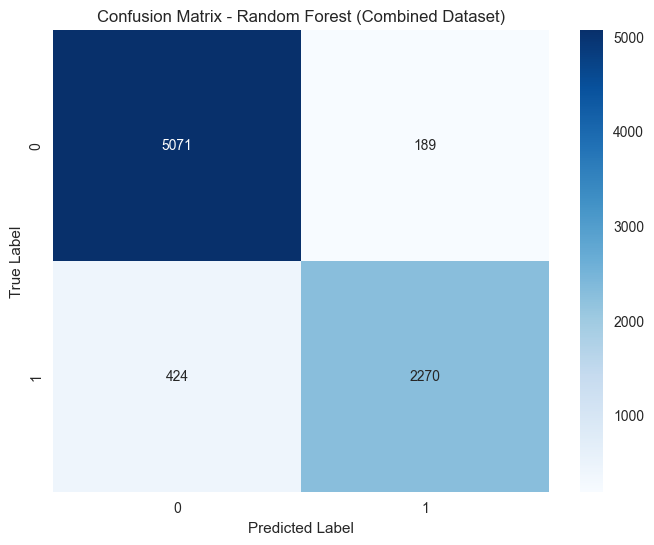

In [40]:
# ------ Combined Dataset Random Forest Classifier -----------
rf_function(X_train_scaled_combined, y_bal_combined, X_test_scaled_combined, y_test_combined, "Combined")